# 0525 練習一、二：W底/M頭與三重頂底

This notebook is the main visual presentation. Core functions are in `src/stock_patterns.py`.

## 1. 匯入函式與設定參數

## Lecture Rules Used Here

This notebook follows the lecture rules strictly. It does not draw a pattern just because the price visually looks similar. A detected pattern must pass the type sequence and neckline confirmation rules below.

The source CSV does not contain `Trend`, so this notebook follows slide 9 of the 0518 lecture: `MA5 > MA10 > MA20` and `Close > MA5` means a bull trend; `MA5 < MA10 < MA20` and `Close < MA5` means a bear trend; every other case means a sideways trend.

Exercise 1 uses every 5 ZigZag turning points as one window. W Bottom requires `a/c/e = peak`, `b/d = valley or flat`, `b` and `d` within 10%, `a >= c`, and a later close breaks above the neckline at `c`. M Top requires `a/c/e = valley`, `b/d = peak or flat`, `b` and `d` within 10%, `a <= c`, and a later close breaks below the neckline at `c`.

Exercise 2 uses every 7 ZigZag turning points as one window. Triple Top requires `p1/p3/p5/p7 = valley`, `p2/p4/p6 = peak or flat`, neckline from `p3` to `p5`, and `p7` close below the projected neckline. Triple Bottom requires `p1/p3/p5/p7 = peak`, `p2/p4/p6 = valley or flat`, neckline from `p3` to `p5`, and `p7` close above the projected neckline.


In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.stock_patterns import (
    clean_zigzag,
    detect_triple_patterns,
    detect_w_m_patterns,
    get_turning_points,
    load_stock_data,
    plot_overview,
    plot_pattern,
    set_chinese_font,
    summarize_patterns,
    select_overview_patterns,
    summarize_windows,
)

set_chinese_font()

STOCK_CODE = "2330"
START_DATE = "2025-01-02"
END_DATE = "2025-12-31"
CSV_PATH = ROOT / "2330_台積電_2025.csv"

ModuleNotFoundError: No module named 'matplotlib'

## 2. Read CSV Data

In [ ]:
df = load_stock_data(STOCK_CODE, START_DATE, END_DATE, csv_path=CSV_PATH)
df.head()

,StockCode,Capacity,Volume,Open,High,Low,Close,Change,Transcation,MA5,MA10,MA20,MA60,MA120,MA240,Trend
Date,,,,,,,,,,,,,,,,
2025-01-02,2330,45045125,47883206644,1070.0,1075.0,1055.0,1065.0,-10.0,74997,1065.000000,1065.000000,1065.000000,1065.000000,1065.000000,1065.000000,橫盤
2025-01-03,2330,31244211,33728652860,1080.0,1085.0,1075.0,1075.0,10.0,28227,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,橫盤
2025-01-06,2330,77874801,86585128825,1100.0,1125.0,1095.0,1125.0,50.0,130021,1088.333333,1088.333333,1088.333333,1088.333333,1088.333333,1088.333333,橫盤
2025-01-07,2330,54691485,62664127156,1150.0,1160.0,1130.0,1130.0,5.0,70657,1098.750000,1098.750000,1098.750000,1098.750000,1098.750000,1098.750000,橫盤
2025-01-08,2330,49181518,54760296689,1110.0,1130.0,1105.0,1105.0,-25.0,71736,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,橫盤


In [ ]:
df[["Open", "High", "Low", "Close", "Volume", "Trend"]].tail()

,Open,High,Low,Close,Volume,Trend
Date,,,,,,
2025-12-24,1495.0,1500.0,1485.0,1495.0,20441056275,上漲
2025-12-26,1505.0,1510.0,1495.0,1510.0,31326715665,上漲
2025-12-29,1515.0,1530.0,1510.0,1530.0,36576386420,上漲
2025-12-30,1515.0,1530.0,1510.0,1520.0,33198645416,上漲
2025-12-31,1520.0,1550.0,1515.0,1550.0,48402721875,上漲


## 3. 產生轉折點與 ZigZag

In [ ]:
turning_points = get_turning_points(df)
zigzag_points = clean_zigzag(turning_points)

print(f"原始轉折點數：{len(turning_points)}")
print(f"整理後 ZigZag 點數：{len(zigzag_points)}")
zigzag_points[:5]

原始轉折點數：33
整理後 ZigZag 點數：24


[{'type': 'flat',
  'date': Timestamp('2025-01-09 00:00:00'),
  'price': 1100.0,
  'group': 1},
 {'type': 'peak',
  'date': Timestamp('2025-01-22 00:00:00'),
  'price': 1150.0,
  'group': 2},
 {'type': 'flat',
  'date': Timestamp('2025-02-03 00:00:00'),
  'price': 1070.0,
  'group': 3},
 {'type': 'peak',
  'date': Timestamp('2025-02-05 00:00:00'),
  'price': 1120.0,
  'group': 4},
 {'type': 'valley',
  'date': Timestamp('2025-02-14 00:00:00'),
  'price': 1060.0,
  'group': 7}]

### Debug: 5-point windows for W/M


In [ ]:
summarize_windows(zigzag_points, 5)


,window,a_type,a_date,a_price,b_type,b_date,b_price,c_type,c_date,c_price,d_type,d_date,d_price,e_type,e_date,e_price
0,1,flat,2025-01-09,1100.0,peak,2025-01-22,1150.0,flat,2025-02-03,1070.0,peak,2025-02-05,1120.0,valley,2025-02-14,1060.0
1,2,peak,2025-01-22,1150.0,flat,2025-02-03,1070.0,peak,2025-02-05,1120.0,valley,2025-02-14,1060.0,flat,2025-02-18,1100.0
2,3,flat,2025-02-03,1070.0,peak,2025-02-05,1120.0,valley,2025-02-14,1060.0,flat,2025-02-18,1100.0,valley,2025-03-19,950.0
3,4,peak,2025-02-05,1120.0,valley,2025-02-14,1060.0,flat,2025-02-18,1100.0,valley,2025-03-19,950.0,flat,2025-03-26,980.0
4,5,valley,2025-02-14,1060.0,flat,2025-02-18,1100.0,valley,2025-03-19,950.0,flat,2025-03-26,980.0,valley,2025-04-09,780.0
5,6,flat,2025-02-18,1100.0,valley,2025-03-19,950.0,flat,2025-03-26,980.0,valley,2025-04-09,780.0,flat,2025-04-17,847.0
6,7,valley,2025-03-19,950.0,flat,2025-03-26,980.0,valley,2025-04-09,780.0,flat,2025-04-17,847.0,valley,2025-04-22,816.0
7,8,flat,2025-03-26,980.0,valley,2025-04-09,780.0,flat,2025-04-17,847.0,valley,2025-04-22,816.0,peak,2025-05-15,1000.0
8,9,valley,2025-04-09,780.0,flat,2025-04-17,847.0,valley,2025-04-22,816.0,peak,2025-05-15,1000.0,flat,2025-05-28,967.0
9,10,flat,2025-04-17,847.0,valley,2025-04-22,816.0,peak,2025-05-15,1000.0,flat,2025-05-28,967.0,peak,2025-06-11,1070.0


### Debug: 7-point windows for Triple Top/Bottom


In [ ]:
summarize_windows(zigzag_points, 7)


,window,a_type,a_date,a_price,b_type,b_date,b_price,c_type,c_date,c_price,...,d_price,e_type,e_date,e_price,f_type,f_date,f_price,g_type,g_date,g_price
0,1,flat,2025-01-09,1100.0,peak,2025-01-22,1150.0,flat,2025-02-03,1070.0,...,1120.0,valley,2025-02-14,1060.0,flat,2025-02-18,1100.0,valley,2025-03-19,950.0
1,2,peak,2025-01-22,1150.0,flat,2025-02-03,1070.0,peak,2025-02-05,1120.0,...,1060.0,flat,2025-02-18,1100.0,valley,2025-03-19,950.0,flat,2025-03-26,980.0
2,3,flat,2025-02-03,1070.0,peak,2025-02-05,1120.0,valley,2025-02-14,1060.0,...,1100.0,valley,2025-03-19,950.0,flat,2025-03-26,980.0,valley,2025-04-09,780.0
3,4,peak,2025-02-05,1120.0,valley,2025-02-14,1060.0,flat,2025-02-18,1100.0,...,950.0,flat,2025-03-26,980.0,valley,2025-04-09,780.0,flat,2025-04-17,847.0
4,5,valley,2025-02-14,1060.0,flat,2025-02-18,1100.0,valley,2025-03-19,950.0,...,980.0,valley,2025-04-09,780.0,flat,2025-04-17,847.0,valley,2025-04-22,816.0
5,6,flat,2025-02-18,1100.0,valley,2025-03-19,950.0,flat,2025-03-26,980.0,...,780.0,flat,2025-04-17,847.0,valley,2025-04-22,816.0,peak,2025-05-15,1000.0
6,7,valley,2025-03-19,950.0,flat,2025-03-26,980.0,valley,2025-04-09,780.0,...,847.0,valley,2025-04-22,816.0,peak,2025-05-15,1000.0,flat,2025-05-28,967.0
7,8,flat,2025-03-26,980.0,valley,2025-04-09,780.0,flat,2025-04-17,847.0,...,816.0,peak,2025-05-15,1000.0,flat,2025-05-28,967.0,peak,2025-06-11,1070.0
8,9,valley,2025-04-09,780.0,flat,2025-04-17,847.0,valley,2025-04-22,816.0,...,1000.0,flat,2025-05-28,967.0,peak,2025-06-11,1070.0,flat,2025-06-23,1020.0
9,10,flat,2025-04-17,847.0,valley,2025-04-22,816.0,peak,2025-05-15,1000.0,...,967.0,peak,2025-06-11,1070.0,flat,2025-06-23,1020.0,peak,2025-07-31,1165.0


## 4. 練習一：偵測 W底 / M頭

In [ ]:
wm_patterns = detect_w_m_patterns(zigzag_points, df=df)
summarize_patterns(wm_patterns)

,pattern,start,end,confirm_date,confirm_price,confirmed
0,W底,2025-10-31,2025-12-31,2025-12-31,1550.0,True


## 5. 練習二：偵測 三重頂 / 三重底

In [ ]:
triple_patterns = detect_triple_patterns(zigzag_points, df=df)
summarize_patterns(triple_patterns)

,pattern,start,end,confirm_date,confirm_price,confirmed
0,三重底,2025-05-15,2025-08-13,2025-08-13,1200.0,True
1,三重底,2025-06-11,2025-10-31,2025-10-31,1500.0,True
2,三重底,2025-08-13,2025-12-31,2025-12-31,1550.0,True


## 6. 繪製個別型態

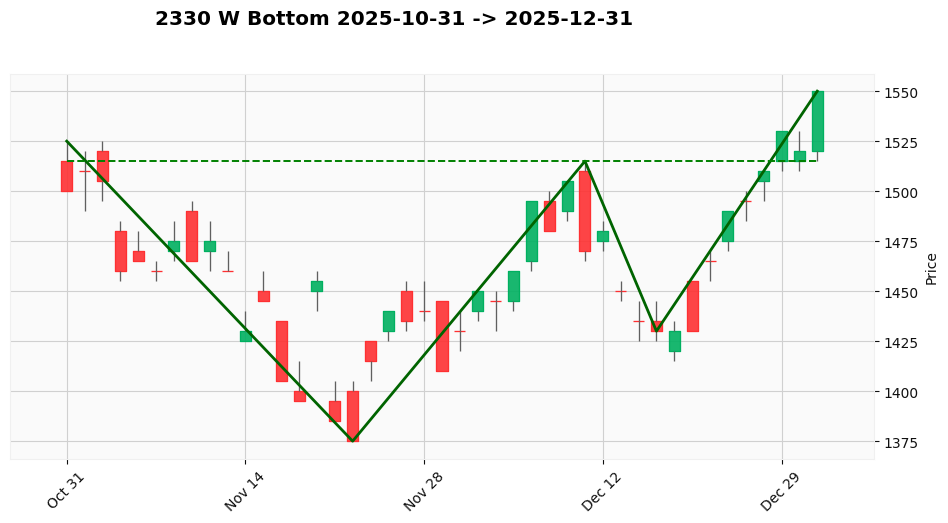

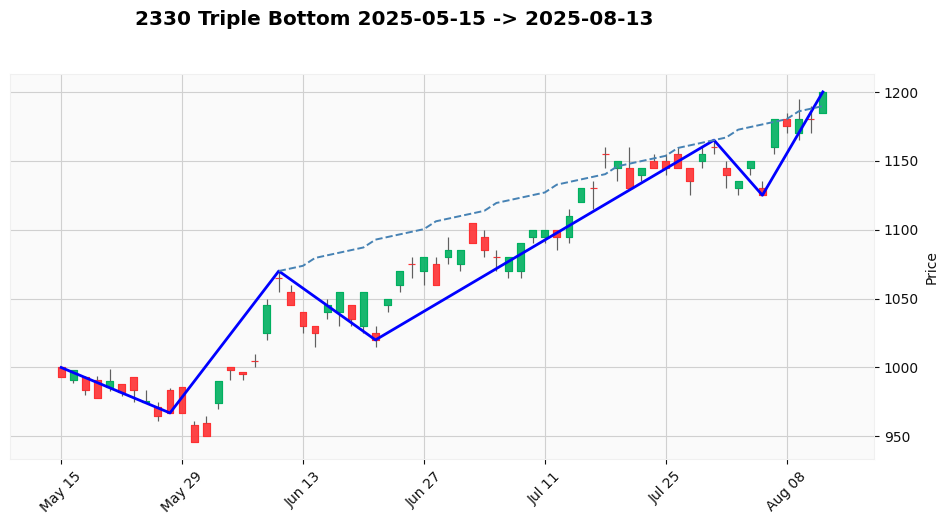

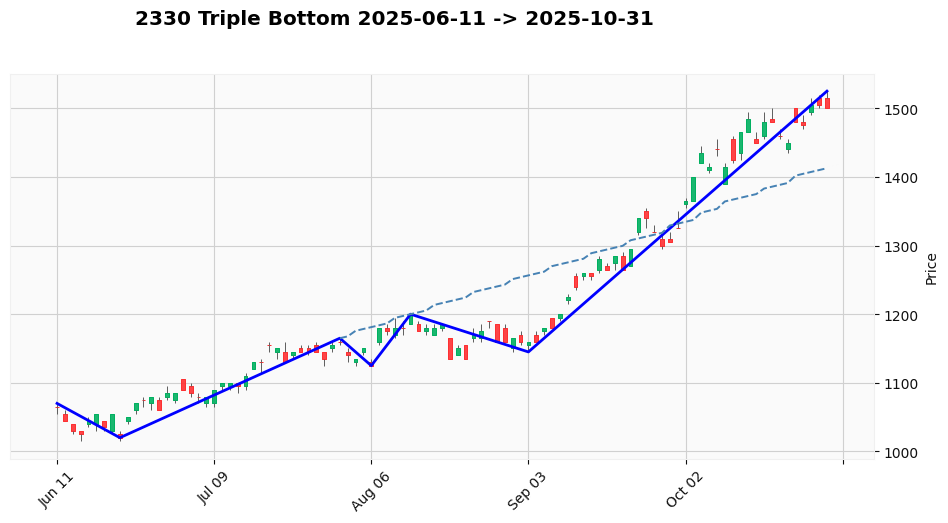

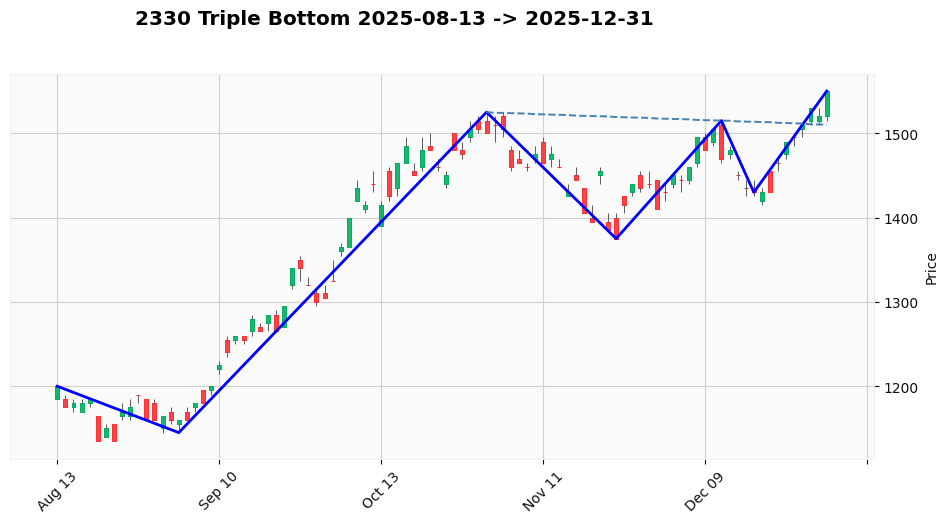

In [ ]:
all_patterns = wm_patterns + triple_patterns

for pattern in all_patterns:
    plot_pattern(df, pattern, stock_code=STOCK_CODE)

## 7. Exercise 1 Overview: M/W Patterns

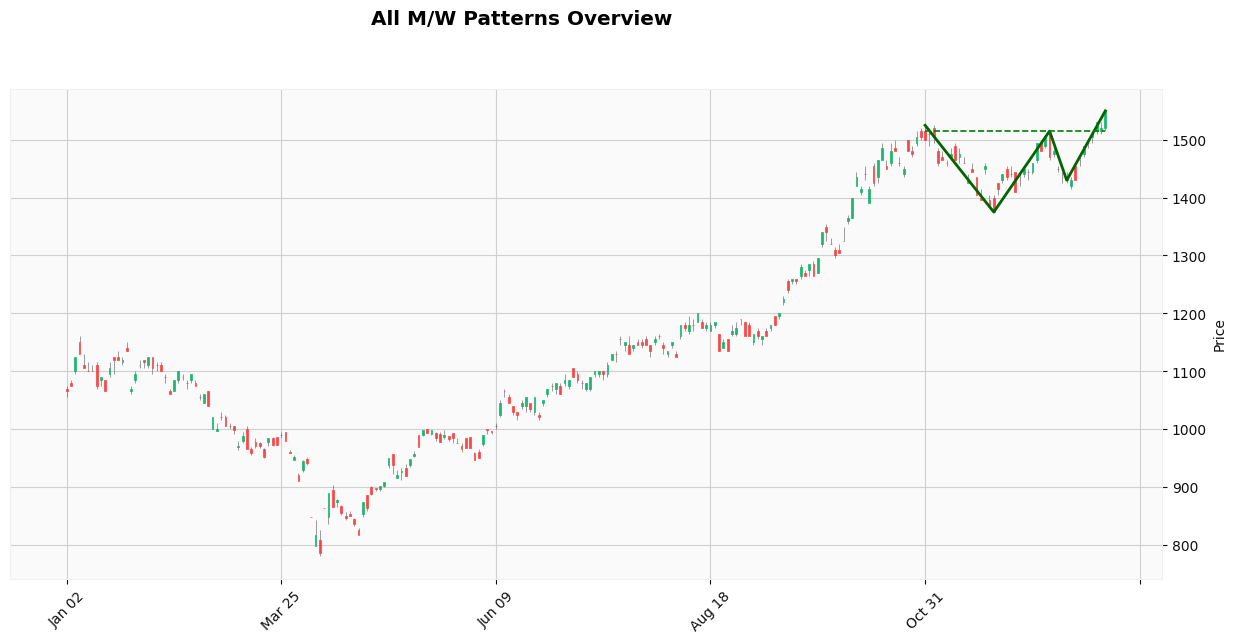

In [ ]:
wm_overview_patterns = select_overview_patterns(wm_patterns)

if wm_overview_patterns:
    plot_overview(df, wm_overview_patterns, stock_code=STOCK_CODE, title="All M/W Patterns Overview")
else:
    print("No W Bottom / M Top patterns detected.")

## 8. Exercise 2 Overview: Triple Top & Bottom


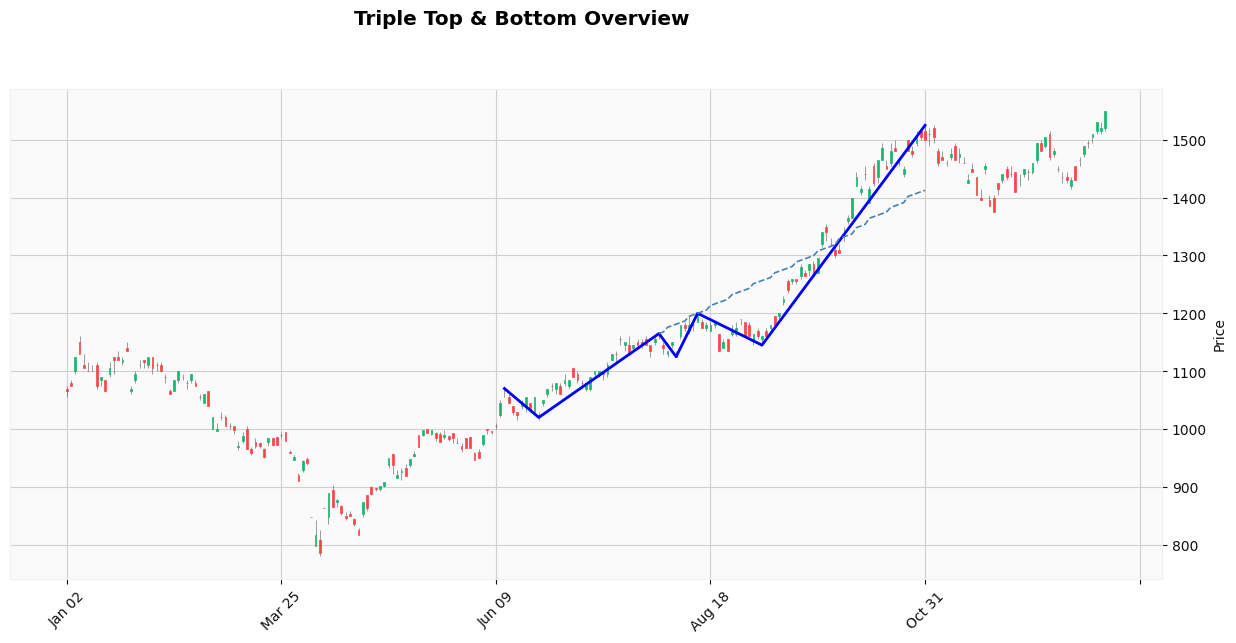

In [ ]:
triple_overview_patterns = select_overview_patterns(triple_patterns)

if triple_overview_patterns:
    plot_overview(df, triple_overview_patterns, stock_code=STOCK_CODE, title="Triple Top & Bottom Overview")
else:
    print("No Triple Top / Triple Bottom patterns detected.")
